# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

Smallest MSE is 372.3312921517965 with alpha = 2.2737367544323206e-13


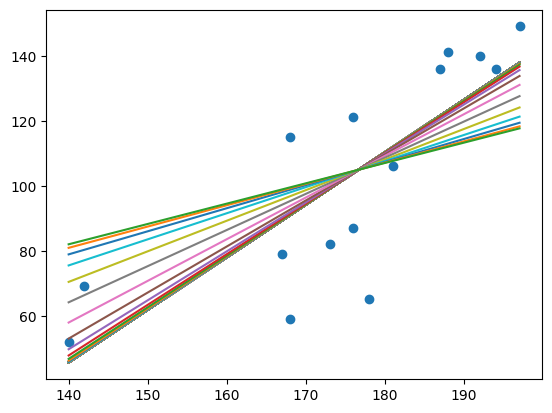

In [7]:
x_in = [188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]
y_in = [141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]

x = np.array(x_in).reshape(-1, 1).reshape(15,1)
y = np.array(y_in).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
eval = lambda x, w: np.min(x) * w[:,1].item() + w[:,0].item()
alphas = [2**n for n in range(-100, 3)]
results = []
errors = []

for alpha in alphas:
	w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
	w = w.ravel()
	results.append(w)
	errors.append(sum(map(lambda n: n**2, [y - eval(x, w) for x, y in zip(x_in, y_in)])) / len(x_in))

print(f"Smallest MSE is {np.min(errors)} with alpha = {alphas[np.argmin(errors)]}")
plt.scatter(x_in, y_in)
for (alpha, result) in zip(alphas, results):
	plt.plot([np.min(x_in), np.max(x_in)], [eval(np.min(x_in), result), eval(np.max(x_in), result)])

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [8]:
def sgd():
    # your code goes here
    pass

In [9]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 


w = np.linalg.inv(x.T*x + alpha * I)*x.T*y # update this line
w=w.ravel()


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df.head()

x = iris_df['sepal width (cm)'].values # change here
y = iris_df['sepal length (cm)'].values # change here

dataset_size = np.size(x)

mean_x, mean_y = np.mean(x), np.mean(y)

SS_xy = np.sum(y * x) - dataset_size * mean_y * mean_x
SS_xx = np.sum(x * x) - dataset_size * mean_x * mean_x

a = SS_xy / SS_xx
b = mean_y - a * mean_x


y_pred = a * x + b